In [31]:
import numpy as np
from dataclasses import dataclass
from functools import partial

import matplotlib.pyplot as plt

import torch

from lingua.optim import build_optimizer, OptimArgs

First lr: 0.0
Peak lr: 0.0003
Last lr: 3.0104080107502407e-05


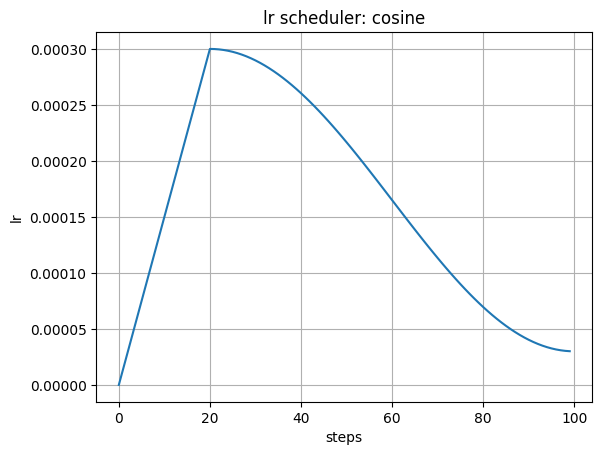

In [47]:
# now plot the lr as a function of step

# overrides = {
#     "scheduler": "cosine",
#     "warmup": 20,
#     "lr": 1.0e-3,
#     "lr_min_ratio": 0.000001,
# }
overrides = {
    "scheduler": "cosine",
    "warmup": 20,
    "lr": 3.0e-4,
    "lr_min_ratio": 1.0e-1,
}
# overrides = {
#     "scheduler": "wsd",
#     "warmup": 20,
#     "lr": 2e-3,
#     "lr_min_ratio": 1e-6,
#     "decay_fraction": 0.1, # fraction of the total steps for decay
#     # "lin_decay": False,
#     "lin_decay": True,
# }
args = OptimArgs(**overrides)

n_steps = 100

# fake model with one parameter
class FakeModule(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(10, 10)

    def forward(self, x):
        return x
    def __repr__(self):
        return "fake model"
model = FakeModule()

optimizer, scheduler = build_optimizer(model, args, n_steps)

# all_lrs = [lr_fn(i) for i in range(n_steps)]
all_lrs = []
for i in range(n_steps):
    all_lrs.append(optimizer.param_groups[0]["lr"])
    optimizer.step()
    scheduler.step()

print(f"First lr: {all_lrs[0]}")
print(f"Peak lr: {max(all_lrs)}")
print(f"Last lr: {all_lrs[-1]}")

x = np.arange(n_steps)
y = np.array(all_lrs)
plt.plot(x, y)
plt.xlabel("steps")
plt.ylabel("lr")
plt.title(f"lr scheduler: {args.scheduler}")
plt.grid()